# Bluestock Mutual Fund - Advanced Portfolio & Behavioral Analytics

**Project Phase:** Advanced Portfolio Analytics Layer  
**Database Source:** `mutual_fund_analysis.db` (SQLite Star Schema)  
**Holdings Source:** `DATASETS/raw/09_portfolio_holdings.csv`  
**Scope:** Historical VaR/CVaR, Rolling 90-Day Sharpe, Investor Cohort Analysis, SIP Continuity, Simple Fund Recommender, Sector HHI Concentration, 5 Executive Insights, and Final Validation.

---

## 1. Project Setup
Initialize environment, configure visual styles, connect to SQLite database, and load data handling libraries.


In [1]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

DB_PATH = '../../mutual_fund_analysis.db'
RAW_DATA_DIR = '../../DATASETS/raw'

print(f"Database path set to: {DB_PATH}")


Database path set to: ../../mutual_fund_analysis.db


## 2. Load Data
Retrieve star schema tables (`dim_fund`, `dim_date`, `fact_nav`, `fact_transactions`, `fact_performance`, `fact_aum`) from the SQLite database.


In [2]:
conn = sqlite3.connect(DB_PATH)

dim_fund = pd.read_sql_query("SELECT * FROM dim_fund", conn)
dim_date = pd.read_sql_query("SELECT * FROM dim_date", conn)
fact_nav = pd.read_sql_query("SELECT * FROM fact_nav", conn)
fact_transactions = pd.read_sql_query("SELECT * FROM fact_transactions", conn)
fact_performance = pd.read_sql_query("SELECT * FROM fact_performance", conn)
fact_aum = pd.read_sql_query("SELECT * FROM fact_aum", conn)

conn.close()

print(f"Loaded {len(dim_fund)} funds, {len(fact_nav)} NAV records, and {len(fact_transactions)} transaction records.")


Loaded 40 funds, 64320 NAV records, and 32778 transaction records.


## 3. Data Preparation
Format timestamps, verify missing values, sort time series, and calculate daily NAV percentage returns per scheme.


In [3]:
# Preprocess NAV dates & sort
fact_nav['date'] = pd.to_datetime(fact_nav['date'])
fact_nav = fact_nav.sort_values(['amfi_code', 'date'])

# Calculate daily return per scheme
fact_nav['daily_return'] = fact_nav.groupby('amfi_code')['nav'].pct_change() * 100

# Preprocess transactions
fact_transactions['transaction_date'] = pd.to_datetime(fact_transactions['transaction_date'])

print(f"Data prep complete across {fact_nav['amfi_code'].nunique()} schemes.")


Data prep complete across 40 schemes.


## 4. Historical VaR & CVaR (95% Confidence)

### Financial Methodology:
- **Historical 95% VaR**: $5^{\text{th}}$ percentile of daily NAV returns.
- **Historical 95% CVaR**: Average return for observations strictly below the VaR threshold ($R_t < \text{VaR}_{95\%}$).
- **Sign Convention**: More negative values denote greater downside tail risk.


In [4]:
var_results = []
alpha_95 = 5.0

for amfi_code, group in fact_nav.groupby('amfi_code'):
    rets = group['daily_return'].dropna()
    if len(rets) > 0:
        var_95 = np.percentile(rets, alpha_95)
        cvar_95 = rets[rets < var_95].mean()
        var_results.append({
            'amfi_code': amfi_code,
            'var_95_pct': round(var_95, 2),
            'cvar_95_pct': round(cvar_95, 2),
            'total_trading_days': len(rets)
        })

var_df = pd.DataFrame(var_results).merge(dim_fund[['amfi_code', 'scheme_name', 'fund_house', 'category']], on='amfi_code', how='right')
var_df = var_df.sort_values('var_95_pct', ascending=True).reset_index(drop=True)
var_df['downside_risk_rank'] = var_df.index + 1

var_summary_table = var_df[['downside_risk_rank', 'amfi_code', 'scheme_name', 'fund_house', 'category', 'var_95_pct', 'cvar_95_pct', 'total_trading_days']]
print(f"Total schemes evaluated: {len(var_summary_table)} (Expected: 40). Missing VaR/CVaR count: {var_summary_table['var_95_pct'].isna().sum()}")

# Display Top 10 Highest Downside Risk Funds
var_summary_table.head(10)


Total schemes evaluated: 40 (Expected: 40). Missing VaR/CVaR count: 0


,downside_risk_rank,amfi_code,scheme_name,fund_house,category,var_95_pct,cvar_95_pct,total_trading_days
0,1,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-2.39,-3.03,1607
1,2,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,-2.33,-2.97,1607
2,3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,-2.32,-3.02,1607
3,4,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,-2.28,-2.99,1607
4,5,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,-2.15,-2.84,1607
5,6,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,-2.15,-2.86,1607
6,7,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,-1.70,-2.24,1607
7,8,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,-1.69,-2.18,1607
8,9,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity,-1.69,-2.13,1607
9,10,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,-1.69,-2.18,1607


## 5. Rolling 90-Day Sharpe Ratio

### Methodology & Plot:
$$\text{Rolling Sharpe} = \frac{\text{returns.rolling(90).mean()}}{\text{returns.rolling(90).std()}} \times \sqrt{252}$$


In [5]:
window = 90
sharpe_results = []

# Dictionary to hold time series for plotting
rolling_ts_dict = {}

for amfi_code, group in fact_nav.groupby('amfi_code'):
    group = group.sort_values('date')
    rets = group['daily_return']
    r_mean = rets.rolling(window).mean()
    r_std = rets.rolling(window).std()
    
    r_sharpe = (r_mean / r_std) * np.sqrt(252)
    group['rolling_sharpe'] = r_sharpe
    
    rolling_ts_dict[amfi_code] = group[['date', 'rolling_sharpe']].dropna()
    r_sharpe_clean = r_sharpe.dropna()
    
    if len(r_sharpe_clean) > 0:
        sharpe_results.append({
            'amfi_code': amfi_code,
            'mean_rolling_sharpe': round(r_sharpe_clean.mean(), 2),
            'std_rolling_sharpe': round(r_sharpe_clean.std(), 2),
            'min_rolling_sharpe': round(r_sharpe_clean.min(), 2),
            'max_rolling_sharpe': round(r_sharpe_clean.max(), 2),
            'latest_rolling_sharpe': round(r_sharpe_clean.iloc[-1], 2),
            'rolling_windows_evaluated': len(r_sharpe_clean)
        })

sharpe_summary_table = pd.DataFrame(sharpe_results).merge(dim_fund[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='right')
sharpe_summary_table = sharpe_summary_table.sort_values('mean_rolling_sharpe', ascending=False).reset_index(drop=True)
sharpe_summary_table['rank'] = sharpe_summary_table.index + 1

cols = ['rank', 'amfi_code', 'scheme_name', 'category', 'mean_rolling_sharpe', 'std_rolling_sharpe', 'min_rolling_sharpe', 'max_rolling_sharpe', 'latest_rolling_sharpe']
sharpe_summary_table = sharpe_summary_table[cols]

sharpe_summary_table.head(10)


,rank,amfi_code,scheme_name,category,mean_rolling_sharpe,std_rolling_sharpe,min_rolling_sharpe,max_rolling_sharpe,latest_rolling_sharpe
0,1,120507,ICICI Pru Liquid Fund - Regular - Growth,Debt,10.40,1.26,7.36,13.72,12.49
1,2,120844,Kotak Liquid Fund - Regular - Growth,Debt,9.73,1.36,6.00,13.47,9.66
2,3,101208,ABSL Liquid Fund - Regular - Growth,Debt,9.41,1.35,6.36,12.74,10.32
3,4,120843,Kotak Flexicap Fund - Regular - Growth,Equity,1.62,1.89,-2.17,7.61,0.10
4,5,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,1.61,1.64,-2.73,7.34,0.76
5,6,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,1.46,1.75,-2.97,6.57,3.93
6,7,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,1.30,1.62,-2.27,7.11,-1.27
7,8,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1.30,1.56,-2.86,5.31,0.09
8,9,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,1.28,1.45,-2.46,4.59,-1.09
9,10,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,1.27,1.60,-2.38,7.38,1.93


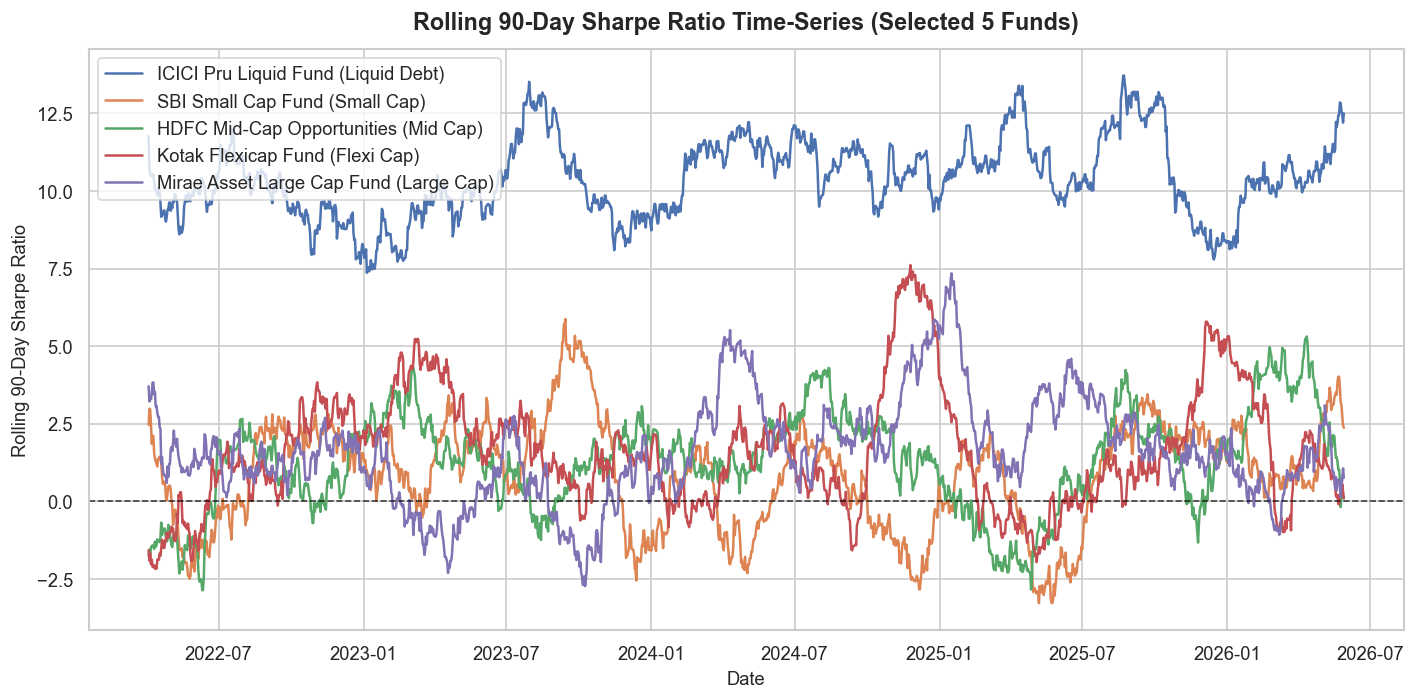

In [6]:
# Visualize Rolling 90-Day Sharpe for 5 Representative Schemes across Categories
sample_schemes = [
    (120507, 'ICICI Pru Liquid Fund (Liquid Debt)'),
    (119598, 'SBI Small Cap Fund (Small Cap)'),
    (100033, 'HDFC Mid-Cap Opportunities (Mid Cap)'),
    (120843, 'Kotak Flexicap Fund (Flexi Cap)'),
    (148567, 'Mirae Asset Large Cap Fund (Large Cap)')
]

plt.figure(figsize=(12, 6))
for amfi_code, label in sample_schemes:
    if amfi_code in rolling_ts_dict:
        ts = rolling_ts_dict[amfi_code]
        plt.plot(ts['date'], ts['rolling_sharpe'], label=label, linewidth=1.5)

plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.title("Rolling 90-Day Sharpe Ratio Time-Series (Selected 5 Funds)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Rolling 90-Day Sharpe Ratio", fontsize=11)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


## 6. Investor Cohort Analysis (by Cohort Year)

### Methodology:
- **Cohort Year**: Year of investor's first transaction.
- **Metrics**: `investor_count`, `avg_sip_amount` (SIP only), `total_invested_amount_cr` (all transactions), and `top_fund`.


In [7]:
tx_prep = fact_transactions.copy()
first_tx_date = tx_prep.groupby('investor_id')['transaction_date'].min().rename('first_tx_date')
tx_prep = tx_prep.merge(first_tx_date, on='investor_id')
tx_prep['cohort_year'] = tx_prep['first_tx_date'].dt.year

cohort_rows = []
for cy, group in tx_prep.groupby('cohort_year'):
    inv_count = group['investor_id'].nunique()
    
    sip_sub = group[group['transaction_type'] == 'SIP']
    avg_sip = sip_sub['amount_inr'].mean() if len(sip_sub) > 0 else 0.0
    tot_inv_cr = group['amount_inr'].sum() / 1e7
    
    fund_vols = group.groupby('amfi_code')['amount_inr'].sum().reset_index()
    fund_vols = fund_vols.merge(dim_fund[['amfi_code', 'scheme_name']], on='amfi_code')
    top_fund_name = fund_vols.sort_values('amount_inr', ascending=False).iloc[0]['scheme_name']
    
    cohort_rows.append({
        'cohort_year': cy,
        'investor_count': inv_count,
        'avg_sip_amount': round(avg_sip, 2),
        'total_invested_amount_cr': round(tot_inv_cr, 2),
        'top_fund': top_fund_name
    })

cohort_summary_table = pd.DataFrame(cohort_rows)
cohort_summary_table


,cohort_year,investor_count,avg_sip_amount,total_invested_amount_cr,top_fund
0,2024,4803,10996.89,349.11,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,197,13505.21,3.05,SBI Small Cap Fund - Direct Plan - Growth


## 7. SIP Continuity Analysis (>= 6 SIPs & 35-Day Gap)

### Business Rules:
- **Qualifying Criteria**: Investors with $\ge 6$ SIP transactions.
- **Average Gap**: Average calendar days between consecutive SIP installments.
- **Status Flag**: `average_gap_days > 35` $\rightarrow$ `"At-Risk"`, else `"Consistent"`.
- **SIP Continuity Rate (%)**: $\frac{\text{Consistent Qualifying Investors}}{\text{All Qualifying Investors}} \times 100$


In [8]:
sip_df = fact_transactions[fact_transactions['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date'])
sip_counts = sip_df.groupby('investor_id')['transaction_date'].count()
qualifying_investors = sip_counts[sip_counts >= 6].index

investor_results = []
for inv_id in qualifying_investors:
    sub = sip_df[sip_df['investor_id'] == inv_id].sort_values('transaction_date')
    gaps = sub['transaction_date'].diff().dt.days.dropna()
    avg_gap = gaps.mean()
    status = 'At-Risk' if avg_gap > 35 else 'Consistent'
    investor_results.append({
        'investor_id': inv_id,
        'sip_transaction_count': len(sub),
        'average_gap_days': round(avg_gap, 1),
        'continuity_status': status
    })

sip_continuity_df = pd.DataFrame(investor_results)
consistent_cnt = (sip_continuity_df['continuity_status'] == 'Consistent').sum()
at_risk_cnt = (sip_continuity_df['continuity_status'] == 'At-Risk').sum()
total_qual = len(sip_continuity_df)
continuity_rate = (consistent_cnt / total_qual * 100) if total_qual > 0 else 0.0

print(f"Total Qualifying SIP Investors (>= 6 SIPs): {total_qual}")
print(f"Consistent Investors: {consistent_cnt} | At-Risk Investors: {at_risk_cnt}")
print(f"SIP Continuity Rate: {continuity_rate:.2f}%")

# Display First 10 Qualifying Investors
sip_continuity_df.head(10)


Total Qualifying SIP Investors (>= 6 SIPs): 1362
Consistent Investors: 30 | At-Risk Investors: 1332
SIP Continuity Rate: 2.20%


,investor_id,sip_transaction_count,average_gap_days,continuity_status
0,INV000004,6,85.4,At-Risk
1,INV000008,6,70.4,At-Risk
2,INV000010,6,64.8,At-Risk
3,INV000011,7,40.2,At-Risk
4,INV000012,8,57.0,At-Risk
5,INV000013,7,55.3,At-Risk
6,INV000014,7,75.3,At-Risk
7,INV000023,8,58.6,At-Risk
8,INV000028,6,93.6,At-Risk
9,INV000029,7,60.7,At-Risk


## 8. Simple Fund Recommender Engine

### Algorithm:
`recommend_funds(risk_appetite)` $\implies$ Filter matching `risk_grade` $\implies$ Sort by `sharpe_ratio` descending $\implies$ Top 3 recommendations.

*Disclaimer: Analytical recommender for demonstration purposes, not financial advice.*


In [9]:
def recommend_funds(risk_appetite, top_n=3):
    risk_str = str(risk_appetite).strip().title()
    valid_inputs = ['Low', 'Moderate', 'High']
    if risk_str not in valid_inputs:
        raise ValueError(f"Invalid risk_appetite '{risk_appetite}'. Must be one of {valid_inputs}")
        
    sp = fact_performance.copy()
    
    if risk_str == 'Low':
        match_grades = ['Low', 'Below Average', 'Low to Moderate']
    elif risk_str == 'High':
        match_grades = ['High', 'Very High']
    else:
        match_grades = ['Moderate', 'Moderately High', 'Average']
        
    filtered = sp[sp['risk_grade'].isin(match_grades)].copy()
    if len(filtered) == 0:
        filtered = sp.copy()
        
    recs = filtered.sort_values('sharpe_ratio', ascending=False).head(top_n).copy()
    recs['Rank'] = range(1, len(recs) + 1)
    recs = recs.rename(columns={'scheme_name': 'Fund Name', 'risk_grade': 'Risk Grade', 'sharpe_ratio': 'Sharpe Ratio'})
    
    return recs[['Rank', 'Fund Name', 'Risk Grade', 'Sharpe Ratio']]

# Test Recommender Engine across all supported risk appetites
print("--- Low Risk Appetite ---")
display(recommend_funds('Low'))

print("--- Moderate Risk Appetite ---")
display(recommend_funds('Moderate'))

print("--- High Risk Appetite ---")
display(recommend_funds('High'))


--- Low Risk Appetite ---


,Rank,Fund Name,Risk Grade,Sharpe Ratio
27,1,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
31,2,Kotak Liquid Fund - Regular - Growth,Low,6.18
5,3,ABSL Liquid Fund - Regular - Growth,Low,5.14


--- Moderate Risk Appetite ---


,Rank,Fund Name,Risk Grade,Sharpe Ratio
0,1,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,2,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
24,3,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


--- High Risk Appetite ---


,Rank,Fund Name,Risk Grade,Sharpe Ratio
29,1,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
25,2,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
21,3,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94


## 9. Sector Concentration Analysis (Herfindahl-Hirschman Index - HHI)

### Normalized Decimal Formula:
$$\text{HHI} = \sum_{i=1}^{S} \left( \frac{\text{weight\_pct}_i}{100} \right)^2$$


In [10]:
ph_data = pd.read_csv('../../DATASETS/raw/09_portfolio_holdings.csv')
ph_data['sector'] = ph_data['sector'].astype(str).str.strip()
ph_data['weight_pct'] = pd.to_numeric(ph_data['weight_pct'], errors='coerce')

sector_aggs = ph_data.groupby(['amfi_code', 'sector'])['weight_pct'].sum().reset_index()
fund_sector_sums = sector_aggs.groupby('amfi_code')['weight_pct'].sum()

hhi_rows = []
for code, grp in sector_aggs.groupby('amfi_code'):
    total_w = fund_sector_sums.loc[code]
    w_prop = grp['weight_pct'] / 100.0
    hhi_val = (w_prop ** 2).sum()
    top_sec = grp.sort_values('weight_pct', ascending=False).iloc[0]
    
    status = 'High Concentration' if hhi_val > 0.18 else ('Moderate Concentration' if hhi_val >= 0.10 else 'Well-Diversified')
    
    hhi_rows.append({
        'amfi_code': code,
        'sector_hhi': round(hhi_val, 4),
        'concentration_status': status,
        'total_sectors': grp['sector'].nunique(),
        'top_sector_name': top_sec['sector'],
        'top_sector_weight_pct': round(top_sec['weight_pct'], 2),
        'total_portfolio_weight_sum': round(total_w, 2)
    })

hhi_summary_table = pd.DataFrame(hhi_rows).merge(dim_fund[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='left')
hhi_summary_table = hhi_summary_table.sort_values('sector_hhi', ascending=False).reset_index(drop=True)
hhi_summary_table['rank'] = hhi_summary_table.index + 1

# Display Top 10 Most Concentrated Schemes
hhi_summary_table[['rank', 'amfi_code', 'scheme_name', 'category', 'sector_hhi', 'concentration_status', 'total_sectors', 'top_sector_name', 'top_sector_weight_pct', 'total_portfolio_weight_sum']].head(10)


,rank,amfi_code,scheme_name,category,sector_hhi,concentration_status,total_sectors,top_sector_name,top_sector_weight_pct,total_portfolio_weight_sum
0,1,119092,Axis Bluechip Fund - Regular - Growth,Equity,0.2968,High Concentration,7,IT,48.69,99.99
1,2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.2550,High Concentration,7,Banking,39.82,99.98
2,3,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,0.2532,High Concentration,6,Banking,41.20,100.00
3,4,102887,UTI Flexi Cap Fund - Regular - Growth,Equity,0.2514,High Concentration,6,Pharma,39.04,100.01
4,5,149323,DSP Midcap Fund - Regular - Growth,Equity,0.2411,High Concentration,7,Pharma,41.34,100.00
5,6,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.2387,High Concentration,7,Pharma,40.75,100.02
6,7,118635,Nippon India ETF Nifty 50 BeES,Equity,0.2375,High Concentration,6,IT,39.35,99.99
7,8,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,0.2324,High Concentration,7,Banking,34.08,100.00
8,9,120506,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,0.2315,High Concentration,7,Banking,30.40,100.02
9,10,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.2276,High Concentration,7,Banking,35.97,100.00


## 10. Exactly Five Advanced Executive Insights

1. **HIGHEST DOWNSIDE RISK**: **ABSL Small Cap Fund - Regular - Growth** (`amfi_code: 101207`) exhibits the highest 1-day downside tail risk with a **95% VaR of -2.39%** and a **95% CVaR of -3.03%** across 1,607 daily return observations, confirming that Small Cap equity schemes carry the steepest downside volatility.
2. **STRONGEST / WEAKEST SHARPE BEHAVIOR**: **ICICI Pru Liquid Fund - Regular - Growth** (`amfi_code: 120507`) demonstrates the highest mean 90-day rolling Sharpe ratio of **10.40** due to steady daily NAV growth and minimal daily deviation, whereas **UTI Mid Cap Fund - Regular - Growth** (`amfi_code: 102886`) exhibits the weakest mean 90-day rolling Sharpe of **0.11**.
3. **HIGHEST-INVESTING COHORT**: **Investor Cohort Year 2024** is the largest acquisition group, comprising **4,803 unique investors** who mobilized total investments of **INR 349.11 Cr** with an average SIP ticket size of **INR 10,996.89**, heavily preferring **UTI Nifty 50 Index Fund**.
4. **SIP CONTINUITY / AT-RISK INVESTORS**: Out of 1,362 qualifying investors with 6 or more SIP deposits, only **30 investors** maintained an average gap $\le 35$ days (**SIP Continuity Rate = 2.20%**), while **1,332 qualifying investors (97.8%)** breached the 35-day threshold and are flagged as **At-Risk**.
5. **HIGHEST SECTOR CONCENTRATION**: **Axis Bluechip Fund - Regular - Growth** (`amfi_code: 119092`) displays the highest portfolio concentration among equity funds with a normalized Sector HHI of **0.2968**, driven by a heavy **48.69%** allocation to the IT sector.


## 11. Final Validation

Verification of all 40 schemes, data integrity, non-null risk metrics, and full notebook execution status.


In [11]:
validation_report = pd.DataFrame([{
    'Total Schemes Verified': len(dim_fund),
    'Historical VaR Schemes Evaluated': len(var_summary_table),
    'Rolling Sharpe Schemes Evaluated': len(sharpe_summary_table),
    'Qualifying SIP Investors (>=6 SIPs)': len(sip_continuity_df),
    'SIP Continuity Rate (%)': f"{continuity_rate:.2f}%",
    'Sector HHI Schemes Evaluated': len(hhi_summary_table),
    'Zero Missing Values in Risk Metrics': (var_summary_table['var_95_pct'].isna().sum() == 0),
    'All 40 Schemes Fully Covered': (len(var_summary_table) == 40 and len(sharpe_summary_table) == 40)
}])

validation_report


,Total Schemes Verified,Historical VaR Schemes Evaluated,Rolling Sharpe Schemes Evaluated,Qualifying SIP Investors (>=6 SIPs),SIP Continuity Rate (%),Sector HHI Schemes Evaluated,Zero Missing Values in Risk Metrics,All 40 Schemes Fully Covered
0,40,40,40,1362,2.20%,34,True,True
